In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np
import sys
# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames
# Gestión de los warnings
# -------------------------------------------------
import warnings
warnings.filterwarnings("ignore")
import os
# Importaciones funciones propias
# -------------------------------------------------
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
 sys.path.append(project_root)
 


# Análisis Exploratorio de Datos (EDA) - Catálogo de Netflix
Este notebook documenta el pipeline completo y ordenado del proyecto: **Carga (Raw) ➔ Inspección ➔ Limpieza (Clean) ➔ Ingeniería de Características (Features) ➔ Visualización (Viz)**.

### 1. Configuración del Entorno e Importaciones
En esta primera etapa, enlazamos la carpeta de scripts `src/` de forma dinámica para poder reutilizar nuestras funciones modulares y configuramos las rutas del proyecto.

In [5]:
import sys
import os
import pandas as pd

# Permitir que el notebook localice e importe desde la carpeta 'src'
sys.path.append(os.path.abspath('../'))

# Importaciones exactas de tus archivos modulares
from src.config import RAW_PATH
from src.io import load_csv
from src.cleaning import clean
from src.viz import (
    plot_content_type,
    plot_movie_duration,
    plot_top_countries,
    plot_seasonality,
    plot_evolution
)

print("✅ Entorno configurado y funciones modulares importadas con éxito.")

✅ Entorno configurado y funciones modulares importadas con éxito.


## 2. Apertura de Datos y Diagnóstico de Calidad (Raw Data)
El primer paso con los datos "en sucio" es cargarlos e inspeccionar su estructura interna. Evaluaremos los tipos de datos asignados por defecto y, lo más importante, buscaremos **valores nulos (missing values)** para diseñar nuestra estrategia de limpieza.

In [6]:
# Proceso 1: Apertura de datos mediante nuestra función en src/io.py
df_raw = load_csv(RAW_PATH)

print("\n📊 2.1. Dimensiones originales del dataset:")
print(f"Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")

print("\n📋 2.2. Vista previa de los primeros 3 registros:")
display(df_raw.head(3))

print("\n🔍 2.3. Diagnóstico de valores nulos detectados por columna:")
print(df_raw.isnull().sum())

✅ Archivo cargado con éxito. Registros: 8807, Columnas: 12

📊 2.1. Dimensiones originales del dataset:
Filas: 8807 | Columnas: 12

📋 2.2. Vista previa de los primeros 3 registros:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...



🔍 2.3. Diagnóstico de valores nulos detectados por columna:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


## 3. Fase de Limpieza de Datos e Ingeniería de Características
Basándonos en el diagnóstico anterior, ejecutamos nuestro proceso de transformación (`src/cleaning.py`) para resolver los siguientes problemas del dataset:
1. **Imputación de textos nulos:** Columnas masivas como `director`, `cast` y `country` se rellenan con la etiqueta `'Unknown'` para no perder filas valiosas.
2. **Imputación estadística:** La columna `rating` se rellena usando su moda (el valor más frecuente).
3. **Conversión Temporal:** La fecha `date_added` se transforma a un formato `datetime` real de Pandas.
4. **Feature Engineering (Nuevas Variables):** Extraemos `year_added` y `month_added` para los análisis de tendencias.
5. **Procesamiento de Duraciones:** Extraemos el número puro de la columna `duration` hacia `duration_num` para poder realizar cálculos matemáticos e histogramas.

In [7]:
# Proceso 2: Aplicación de la limpieza y transformaciones masivas
df_clean = clean(df_raw)

print("\n✨ 3.1. Verificación de nulos tras la limpieza en las columnas transformadas:")
print(df_clean[['director', 'cast', 'country', 'rating', 'date_added', 'duration_num']].isnull().sum())

print("\n🚀 3.2. Muestra de las nuevas características (Features) creadas:")
display(df_clean[['title', 'type', 'year_added', 'month_added', 'duration_num', 'duration_unit']].head(4))

🧹 Datos limpios y procesados. Registros finales: 8807

✨ 3.1. Verificación de nulos tras la limpieza en las columnas transformadas:
director         0
cast             0
country          0
rating           0
date_added      10
duration_num     3
dtype: int64

🚀 3.2. Muestra de las nuevas características (Features) creadas:


,title,type,year_added,month_added,duration_num,duration_unit
0,Dick Johnson Is Dead,Movie,2021,September,90.0,min
1,Blood & Water,TV Show,2021,September,2.0,Seasons
2,Ganglands,TV Show,2021,September,1.0,Season
3,Jailbirds New Orleans,TV Show,2021,September,1.0,Season


## 4. Análisis Exploratorio Visual (EDA)
Con un dataset limpio y estructurado bajo el pipeline, pasamos a responder nuestras preguntas de investigación mediante visualizaciones diseñadas bajo el principio de alta relación dato/tinta (quitando bordes innecesarios con despine y usando colores institucionales).

### Pregunta 1: ¿El catálogo de Netflix está dominado por películas o por series de televisión?
*Hipótesis:* Históricamente los largometrajes dominan el catálogo, pero analizaremos la proporción total de títulos.

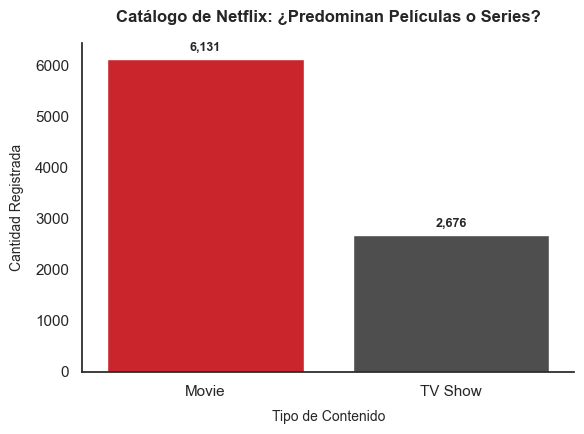

In [8]:
plot_content_type(df_clean)


### Pregunta 2: ¿Cuál es la duración promedio de las películas en Netflix y cómo se distribuye?
*Hipótesis:* La distribución se concentrará fuertemente alrededor del estándar comercial de 90 a 110 minutos.

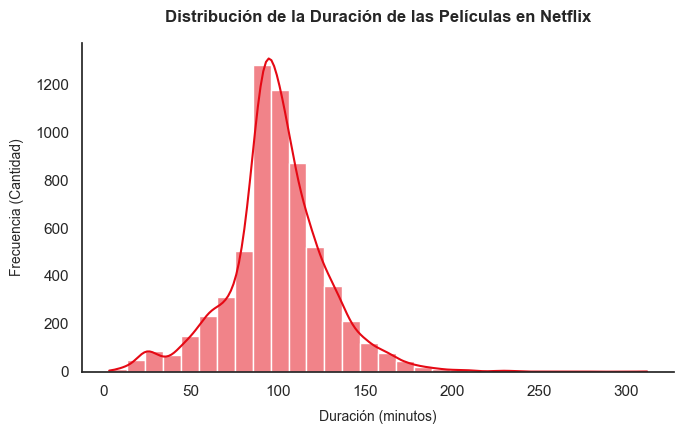

In [9]:
plot_movie_duration(df_clean)

### Pregunta 3: ¿Cuáles son los 5 países que más contenido producen para la plataforma?
*Hipótesis:* Estados Unidos e India liderarán debido al tamaño de sus industrias cinematográficas y de entretenimiento.

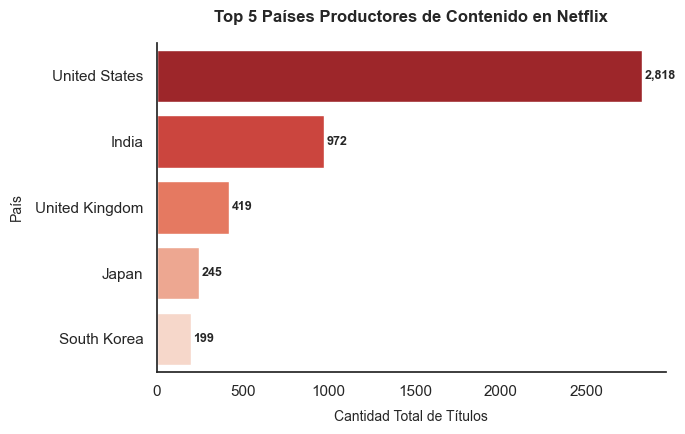

In [10]:
plot_top_countries(df_clean)

### Pregunta 4: ¿Existe estacionalidad en la adición de contenido a la plataforma?
*Hipótesis:* Los meses cercanos al cierre de año (Octubre - Diciembre) concentrarán más lanzamientos aprovechando las vacaciones de invierno.

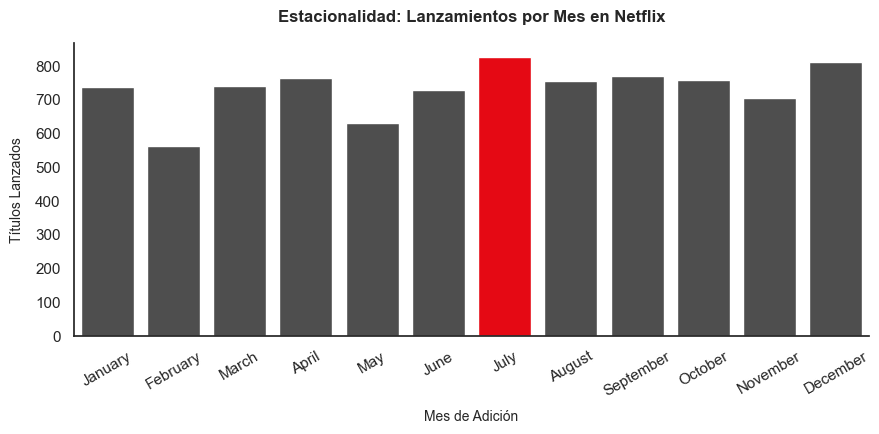

In [12]:
plot_seasonality(df_clean)

### Pregunta 5: ¿Cómo ha cambiado la estrategia de adición de Películas vs. Series a lo largo de los años?
*Hipótesis:* En los últimos años, Netflix ha incrementado exponencialmente la incorporación de series frente a películas para retener usuarios en su plataforma por más tiempo.

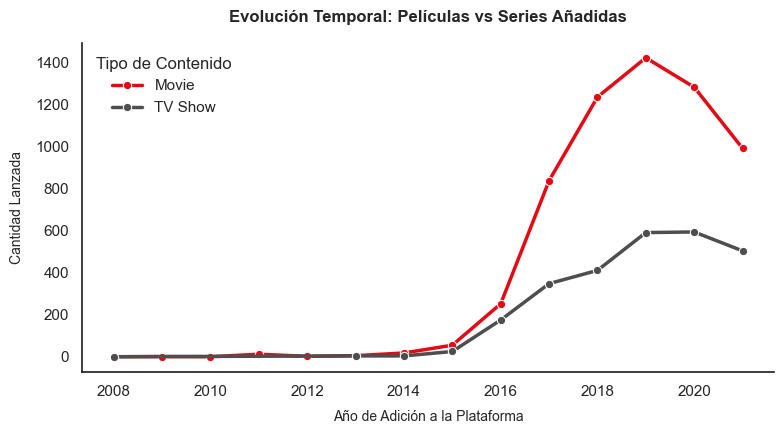

In [13]:
plot_evolution(df_clean)

## 5. Conclusiones Generales del Proyecto
Tras construir el pipeline e interrogar al dataset con gráficos explicativos, se obtienen los siguientes hallazgos (insights):

1. **Predominio Cinematográfico:** El catálogo histórico está compuesto mayoritariamente por películas (más de un 60%), superando ampliamente el volumen total de series.
2. **Distribución de Duración Estándar:** Las películas siguen una distribución normal muy marcada con un pico claro en los **90-100 minutos**, validando que Netflix mantiene los formatos cinematográficos comerciales tradicionales.
3. **Concentración de Mercado:** La producción de contenidos está fuertemente centralizada en **Estados Unidos**, que duplica y triplica la oferta de los competidores más cercanos como India y el Reino Unido.
4. **Evolución Estratégica:** Al analizar la línea temporal se observa que, aunque las películas crecieron agresivamente hasta su pico en 2019, la incorporación de series muestra un ritmo de crecimiento sostenido y una brecha cada vez menor, alineándose con las estrategias modernas de retención de usuarios.
